## 1: 环境配置与日志屏蔽
> 说明：设置环境变量以获得干净的输出，并导入所有必要的深度学习组件。

In [17]:
# -*- coding: utf-8 -*-
import os
# 屏蔽 TensorFlow 系统日志，只显示 Error
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import math

from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    InputLayer, Input, Reshape,
    MaxPooling2D, Conv2D, Dense, Flatten
)
from tensorflow.keras.optimizers import Adam

# 在 Jupyter 中开启内联绘图
%matplotlib inline
print("TensorFlow 版本:", tf.__version__)

TensorFlow 版本: 2.20.0


## 2: 数据载入与预处理封装
> 说明：定义数据加载函数和 DataWrapper 类，处理 MNIST 的归一化与维度转换。

In [18]:
# 1.2 载入数据
def load_local_mnist(path):
    with np.load(path, allow_pickle=True) as f:
        x_train, y_train = f['x_train'], f['y_train']
        x_test, y_test = f['x_test'], f['y_test']
    return (x_train, y_train), (x_test, y_test)

# 请确保数据文件路径正确
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_local_mnist('data/mnist.npz')

class DataWrapper:
    def __init__(self, x_train, y_train, x_test, y_test):
        self.img_size = 28
        self.img_size_flat = 784
        self.img_shape = (28, 28)
        self.img_shape_full = (28, 28, 1)
        self.num_classes = 10
        # 预处理：归一化
        self.x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
        self.x_test = x_test.reshape(-1, 784).astype('float32') / 255.0
        # 标签转 One-Hot
        self.y_train = tf.keras.utils.to_categorical(y_train, 10)
        self.y_test = tf.keras.utils.to_categorical(y_test, 10)
        self.y_test_cls = y_test

data = DataWrapper(x_train_raw, y_train_raw, x_test_raw, y_test_raw)
print(f"1.3 配置神经网络 图像尺寸 {data.img_size} 形状 {data.img_shape_full}")

1.3 配置神经网络 图像尺寸 28 形状 (28, 28, 1)


## 3: 绘图工具函数定义
> 说明：定义用于展示图片、错误样本以及卷积特征的辅助函数。

In [19]:
# 1.4 & 1.5 绘图辅助函数
def plot_images(images, cls_true, cls_pred=None):
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i].reshape(28, 28), cmap='binary')
            xlabel = f"True: {cls_true[i]}"
            if cls_pred is not None: xlabel += f"\nPred: {cls_pred[i]}"
            ax.set_xlabel(xlabel)
        ax.set_xticks([]); ax.set_yticks([])
    plt.show()

def plot_example_errors(cls_pred, correct):
    incorrect = (correct == False)
    images = data.x_test[incorrect]
    cls_pred = cls_pred[incorrect]
    cls_true = data.y_test_cls[incorrect]
    print(f"展示前9个预测错误的样本:")
    plot_images(images=images[0:9], cls_true=cls_true[0:9], cls_pred=cls_pred[0:9])

def plot_conv_weights(weights, input_channel=0):
    num_filters = weights.shape[3]
    num_grids = math.ceil(math.sqrt(num_filters))
    fig, axes = plt.subplots(num_grids, num_grids, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        if i < num_filters:
            img = weights[:, :, input_channel, i]
            ax.imshow(img, vmin=np.min(weights), vmax=np.max(weights), cmap='seismic')
        ax.set_xticks([]); ax.set_yticks([])
    plt.show()

def plot_conv_output(values):
    num_filters = values.shape[3]
    num_grids = math.ceil(math.sqrt(num_filters))
    fig, axes = plt.subplots(num_grids, num_grids, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < num_filters:
            ax.imshow(values[0, :, :, i], interpolation='nearest', cmap='binary')
        ax.set_xticks([]); ax.set_yticks([])
    plt.show()

## 4: 序列模型 (Sequential) 训练与评估
> 说明：按照实验 2.x 章节要求，构建并训练模型，查看预测结果与错误分类。

2.3 序列模型训练
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9400 - loss: 0.2095

2.4 序列模型评估结果
loss 0.054842181503772736
compile_metrics 0.982699990272522

2.5 绘制序列模型前九张预测结果


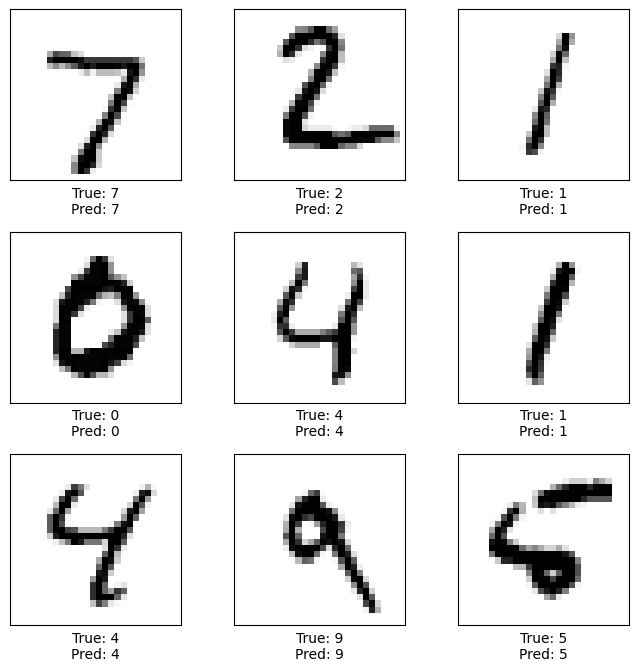


2.6 绘制序列模型错分类样本图片
展示前9个预测错误的样本:


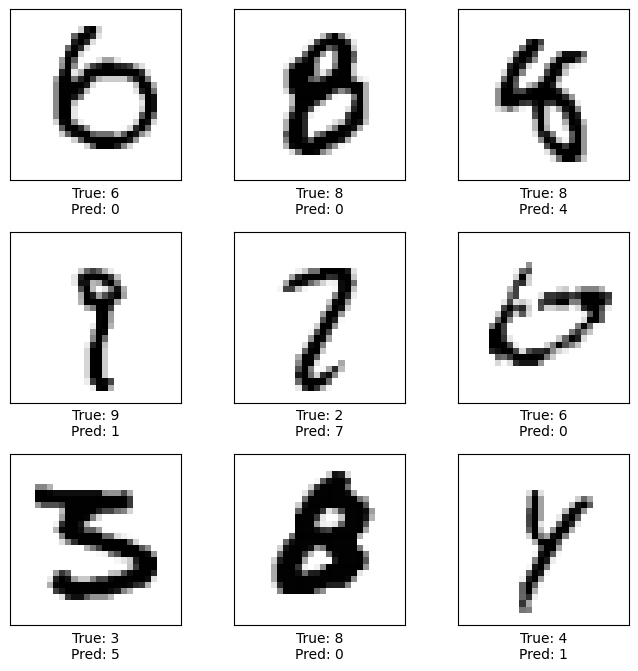

In [20]:
# 2. 序列模型
print("2.3 序列模型训练")
model = Sequential([
    InputLayer(shape=(784,)),
    Reshape((28, 28, 1)),
    Conv2D(kernel_size=5, filters=16, padding='same', activation='relu', name='layer_conv1'),
    MaxPooling2D(pool_size=2, strides=2),
    Conv2D(kernel_size=5, filters=36, padding='same', activation='relu', name='layer_conv2'),
    MaxPooling2D(pool_size=2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x=data.x_train, y=data.y_train, epochs=1, batch_size=128)

print("\n2.4 序列模型评估结果")
result = model.evaluate(x=data.x_test, y=data.y_test, verbose=0)
for name, val in zip(model.metrics_names, result):
    print(name, val)

print("\n2.5 绘制序列模型前九张预测结果")
plot_images(images=data.x_test[0:9], cls_true=data.y_test_cls[0:9], 
            cls_pred=np.argmax(model.predict(data.x_test[0:9], verbose=0), axis=1))

print("\n2.6 绘制序列模型错分类样本图片")
y_pred_all = model.predict(x=data.x_test, verbose=0)
cls_pred_all = np.argmax(y_pred_all, axis=1)
correct_all = (cls_pred_all == data.y_test_cls)
plot_example_errors(cls_pred=cls_pred_all, correct=correct_all)

## 5: 功能模型 (Functional API) 与持久化
> 说明：实现实验 3.x 和 4.x 章节内容，展示模型保存与加载。

3.3 功能模型训练
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9405 - loss: 0.1916

4.1 保存模型并重新加载

4.4 使用加载的模型预测前九张图片
4.4 预测类数为 [7 2 1 0 4 1 4 9 5]
4.4 真实类数为 [7 2 1 0 4 1 4 9 5]


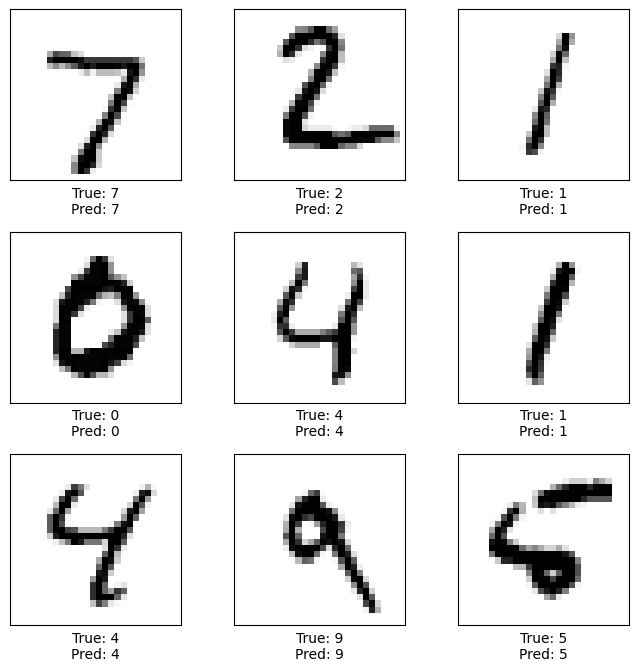

In [21]:
# 3. 功能模型
print("3.3 功能模型训练")
inputs = Input(shape=(784,))
net = Reshape((28, 28, 1))(inputs)
net = Conv2D(kernel_size=5, filters=16, padding='same', activation='relu', name='layer_conv1_func')(net)
net = MaxPooling2D(pool_size=2, strides=2)(net)
net = Conv2D(kernel_size=5, filters=36, padding='same', activation='relu', name='layer_conv2_func')(net)
net = MaxPooling2D(pool_size=2, strides=2)(net)
net = Flatten()(net)
net = Dense(128, activation='relu')(net)
outputs = Dense(10, activation='softmax')(net)

model2 = Model(inputs=inputs, outputs=outputs)
model2.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
model2.fit(x=data.x_train, y=data.y_train, epochs=1, batch_size=128)

# 4. 保存与加载
print("\n4.1 保存模型并重新加载")
model2.save('model.keras')
del model2
model3 = load_model('model.keras')

print("\n4.4 使用加载的模型预测前九张图片")
y_pred_load = np.argmax(model3.predict(data.x_test[0:9], verbose=0), axis=1)
print("4.4 预测类数为", y_pred_load)
print("4.4 真实类数为", data.y_test_cls[0:9])
plot_images(images=data.x_test[0:9], cls_true=data.y_test_cls[0:9], cls_pred=y_pred_load)

## 6: 内部权重可视化
> 说明：展示卷积层 1 和 2 学习到的滤波器。

5.2 模型网络结构摘要


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_conv1_func (Conv2D)       │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_conv2_func (Conv2D)       │ (None, 14, 14, 36)     │        14,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1764)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       225,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,126 (1.85 MB)

 Trainable params: 242,062 (945.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 242,064 (945.57 KB)


5.3 可视化卷积层1权重 (16个滤波器)


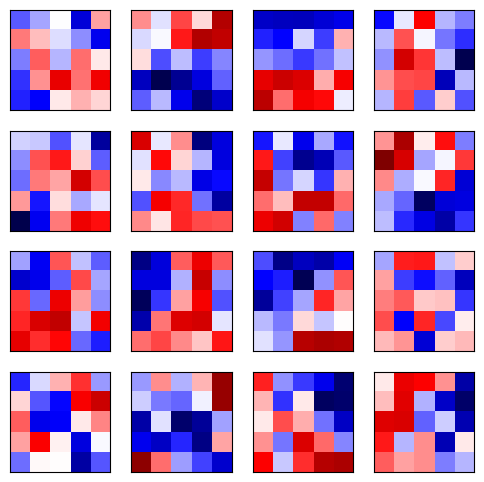


5.3 可视化卷积层2权重 (36个滤波器)


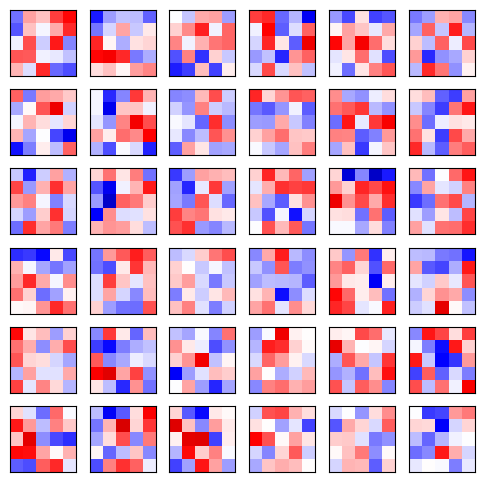

In [22]:
# 5.2 & 5.3 权重可视化
print("5.2 模型网络结构摘要")
model3.summary()

layer_conv1 = model3.get_layer('layer_conv1_func')
layer_conv2 = model3.get_layer('layer_conv2_func')

print("\n5.3 可视化卷积层1权重 (16个滤波器)")
plot_conv_weights(weights=layer_conv1.get_weights()[0])

print("\n5.3 可视化卷积层2权重 (36个滤波器)")
plot_conv_weights(weights=layer_conv2.get_weights()[0])

## 7: 中间层特征图 (Feature Maps) 可视化
> 说明：使用两种方法获取并展示输入图像经过卷积层处理后的结果。

5.5 展示原始输入图像


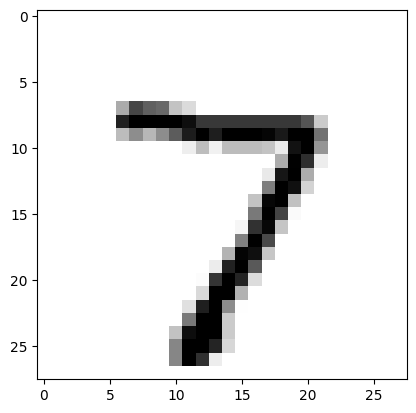


5.6 使用方法一获取卷积层1输出
5.6.2 卷积层1输出形状: (1, 28, 28, 16)


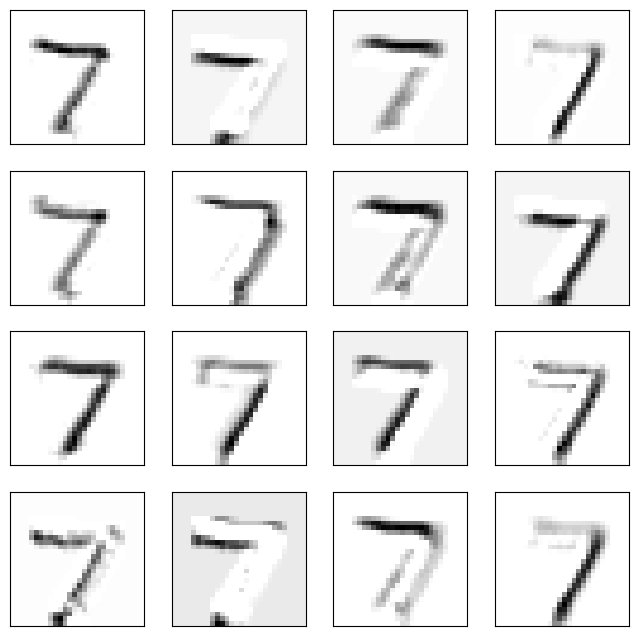


5.7 使用方法二获取卷积层2输出
5.7.2 卷积层2输出形状: (1, 14, 14, 36)


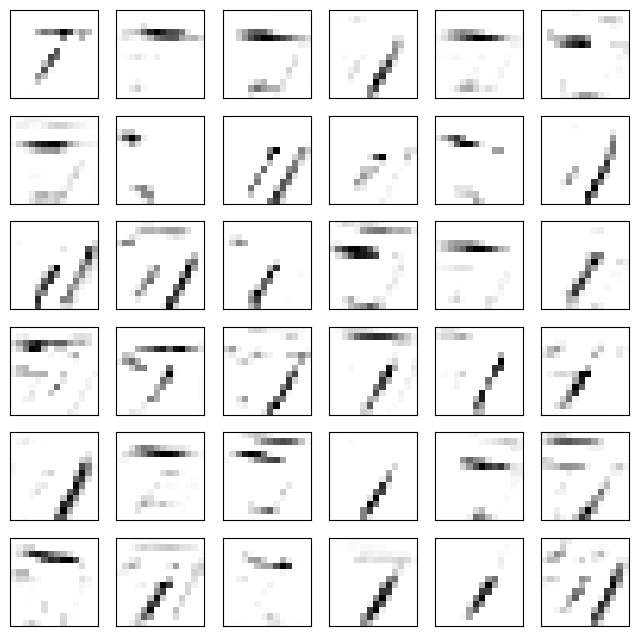

In [23]:
# 5.5 输入图像展示
image1 = data.x_test[0:1]
print("5.5 展示原始输入图像")
plt.imshow(image1.reshape(28,28), cmap='binary')
plt.show()

# 5.6 方法一：模拟 K.function
print("\n5.6 使用方法一获取卷积层1输出")
def K_function_mock(inputs, outputs):
    model_temp = Model(inputs=inputs, outputs=outputs)
    return lambda x: [model_temp(np.array(x[0])).numpy()]

output_conv1 = K_function_mock(inputs=model3.input, outputs=layer_conv1.output)
layer_output1 = output_conv1([image1])[0]
print("5.6.2 卷积层1输出形状:", layer_output1.shape) 
plot_conv_output(values=layer_output1)

# 5.7 方法二：直接使用功能模型预测
print("\n5.7 使用方法二获取卷积层2输出")
output_conv2_model = Model(inputs=model3.input, outputs=layer_conv2.output)
layer_output2 = output_conv2_model.predict(image1, verbose=0)
print("5.7.2 卷积层2输出形状:", layer_output2.shape) 
plot_conv_output(values=layer_output2)